In [1]:
import nltk
print(nltk.__version__)


3.9.2


C:\Users\mar_c\AppData\Local\Temp\ipykernel_35004\2619437633.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2023-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

                Actual   Predicted
Date                              
2024-01-29  189.936249  188.682808
2023-04-19  165.390839  165.281199
2024-02-28  179.952042  179.863885
2023-08-16  174.687958  175.928771
2023-06-02  178.779831  178.126540
Error Cuadrático Medio (MSE): 0.6865536768527098
Puntaje R-cuadrado (R²): 0.9992913890834583


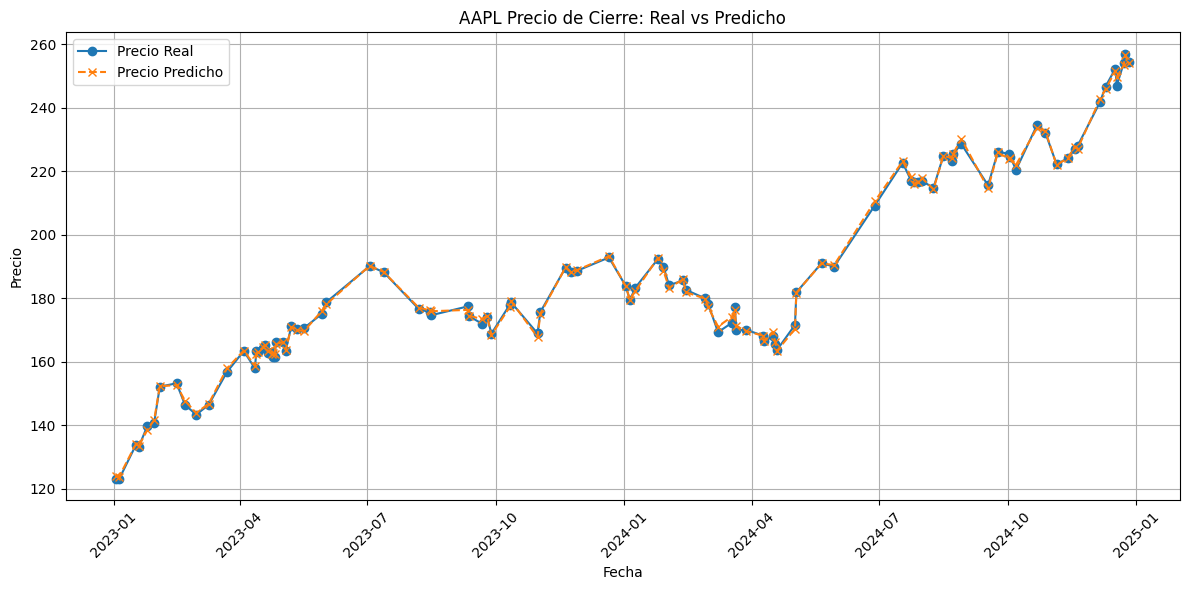

Predicción del siguiente día: [[249.90298248]]


In [2]:
##Predecir como cerrara una acción usando los datos de como empieza el open,hih,low y volume de yahoo finance con regresion lineal

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Descargar datos históricos de Yahoo Finance
ticker = 'AAPL'  # Puedes reemplazarlo por cualquier otro ticker
data = yf.download(ticker, start='2023-01-01', end='2025-01-01')

# Preparar los datos
features = ['Open', 'High', 'Low', 'Volume']  # Variables predictoras
target = 'Close'  # Variable objetivo a predecir
data = data.dropna()  # Eliminar filas con valores faltantes

X = data[features]  # Matriz de características
y = data[target]     # Variable objetivo

# Dividir datos en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones
predictions = model.predict(X_test)

# Mostrar resultados alineados correctamente
results_df = pd.DataFrame({
    'Actual': y_test.values.flatten(),
    'Predicted': predictions.flatten()
}, index=y_test.index)

print(results_df.head())

# Métricas opcionales de evaluación del modelo
mse = mean_squared_error(y_test, predictions)  # Error cuadrático medio
r2 = r2_score(y_test, predictions)  # Coeficiente R²
print(f'Error Cuadrático Medio (MSE): {mse}')
print(f'Puntaje R-cuadrado (R²): {r2}')

# Ordenar resultados por fecha para graficar correctamente
results_df_sorted = results_df.sort_index()

# Graficar los precios reales vs. predichos
plt.figure(figsize=(12, 6))
plt.plot(results_df_sorted.index, results_df_sorted['Actual'],
         label='Precio Real', marker='o', linestyle='-')
plt.plot(results_df_sorted.index, results_df_sorted['Predicted'],
         label='Precio Predicho', linestyle='--', marker='x')

plt.title(f'{ticker} Precio de Cierre: Real vs Predicho')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Predicción del siguiente día (ejemplo)
latest_day_features = X.iloc[-1].values.reshape(1, -1)
next_day_prediction = model.predict(latest_day_features)
print("Predicción del siguiente día:", next_day_prediction)


Epoch 1/20


c:\Users\mar_c\OneDrive\Documentos\Programacion\IA\entorno\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3627.9524    
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 124.3576 
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.7495 
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.8322 
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 22.5385 
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.4655 
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.0310 
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.7022 
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.5280 
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.2495 
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.6408 
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.1971 
Epoch 13/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.3989 
Epoch 14/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.6723 
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.

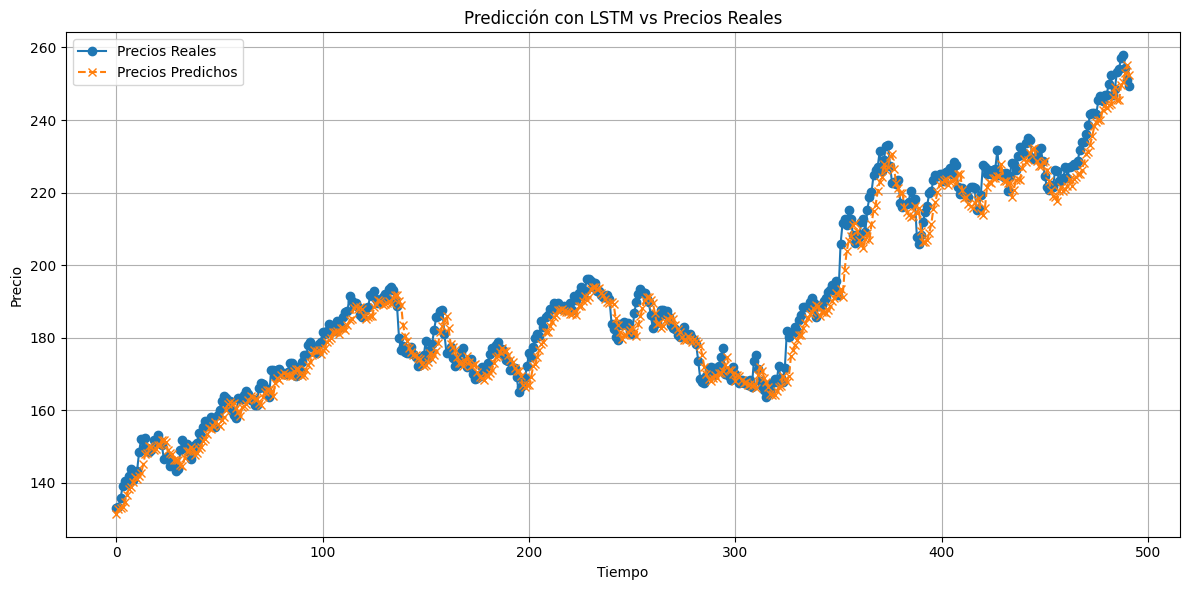

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Predicción del siguiente día: 252.54947


In [3]:
##Predecir el precio de una acción usando LSTM y los datos de cierre de yahoo finance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Preparación de los datos
values = data['Close'].values
X, y = [], []
window_size = 10  # Número de días que se usarán como ventana para predecir el siguiente día

# Crear ventanas deslizantes: secuencias de 10 precios y su siguiente valor como etiqueta
for i in range(len(values) - window_size):
    X.append(values[i:i + window_size])     # Secuencia de entrada
    y.append(values[i + window_size])       # Valor objetivo (día siguiente)

X, y = np.array(X), np.array(y)

# Ajustar X al formato requerido por LSTM: (muestras, pasos de tiempo, características)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Construcción del modelo LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(window_size, 1)))  # 50 neuronas LSTM
model.add(Dense(1))  # Capa de salida para predecir un único valor
model.compile(optimizer='adam', loss='mse')  # MSE como función de pérdida

# Entrenamiento del modelo
history = model.fit(X, y, epochs=20, batch_size=32)

# Realizar predicciones en todo el conjunto
predictions = model.predict(X)

# Graficar valores reales vs. valores predichos
plt.figure(figsize=(12, 6))
plt.plot(y, label='Precios Reales', marker='o')
plt.plot(predictions, label='Precios Predichos', linestyle='--', marker='x')
plt.title('Predicción con LSTM vs Precios Reales')
plt.xlabel('Tiempo')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Predecir el siguiente valor después de la última ventana de 10 días
next_prediction = model.predict(X[-1].reshape(1, window_size, 1))
print("Predicción del siguiente día:", next_prediction.flatten()[0])


Final Q-values:
[[ 0.09745834  0.15777194 -0.11965274]
 [ 0.10663069 -0.015357    0.17459822]
 [ 0.11448095  0.28891643 -0.08432318]]


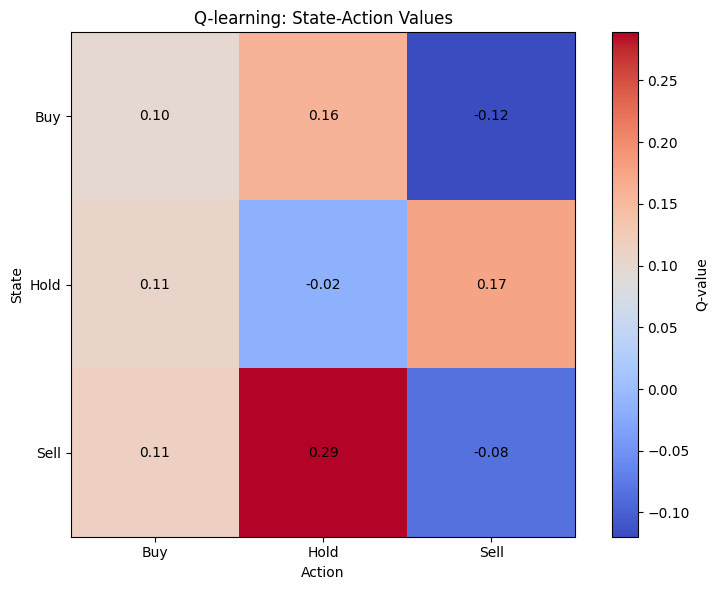

In [ ]:
# Q-learning pertenece al área de Reinforcement Learning (RL).
# Se usa cuando las decisiones financieras:
# dependen de una secuencia de acciones,
# tienen un impacto acumulado en el futuro,
# y hay recompensas o castigos asociados.

import numpy as np
import matplotlib.pyplot as plt

# Definir parámetros del Q-learning
states = ['Buy', 'Hold', 'Sell']
Q = np.zeros((len(states), len(states)))  # Tabla Q: filas=estados, columnas=acciones
learning_rate = 0.1      # Tasa de aprendizaje
discount_factor = 0.95    # Factor de descuento (importancia del futuro)

# Simular un entorno de trading muy simplificado
for episode in range(100):
    state = np.random.choice(states)    # Estado actual al azar
    action = np.random.choice(states)   # Acción tomada al azar
    reward = np.random.randn()          # Recompensa hipotética (ruido aleatorio)

    # Actualizar los valores de la tabla Q usando la regla de Q-learning
    old_value = Q[states.index(state), states.index(action)]
    Q[states.index(state), states.index(action)] = old_value + learning_rate * (
        reward + discount_factor * np.max(Q[states.index(action)]) - old_value)

# Mostrar los valores Q finales
print("Valores Q finales:")
print(Q)

# Graficar la tabla Q como mapa de calor
plt.figure(figsize=(8,6))
plt.imshow(Q, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Valor Q')
plt.xticks(range(len(states)), states)
plt.yticks(range(len(states)), states)
plt.title('Q-learning: Valores Estado-Acción')
plt.xlabel('Acción')
plt.ylabel('Estado')

# Escribir los valores dentro del heatmap
for (j, i), label in np.ndenumerate(Q):
    plt.text(i, j, f'{label:.2f}', ha='center', va='center', color='black')

plt.grid(False)
plt.tight_layout()
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\mar_c\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


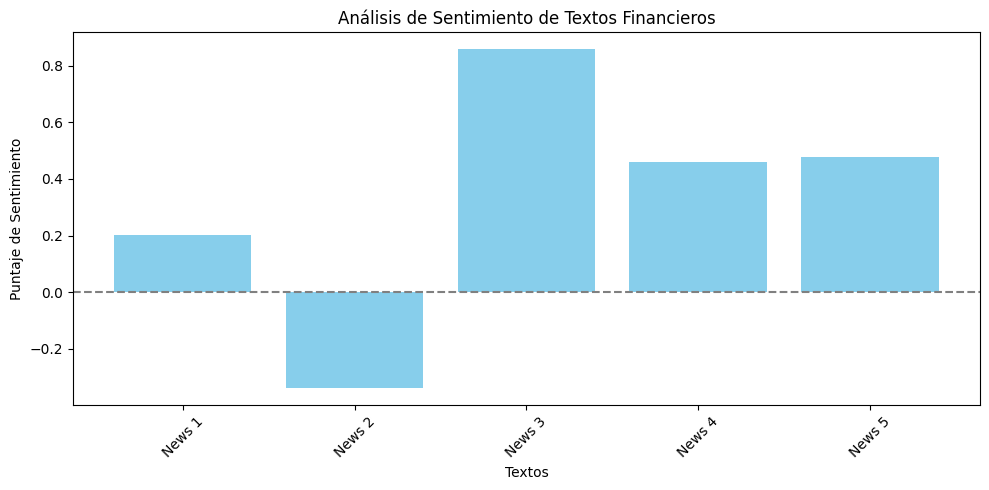

Texto: Company earnings surpassed expectations, leading to a significant stock rise.
Puntaje de Sentimiento: 0.20

Texto: Market uncertainty increases due to global economic slowdown.
Puntaje de Sentimiento: -0.34

Texto: Strong quarterly performance indicates robust growth prospects.
Puntaje de Sentimiento: 0.86

Texto: Investors express concerns about inflation and rising interest rates.
Puntaje de Sentimiento: 0.46

Texto: New product launch receives overwhelmingly positive feedback from consumers.
Puntaje de Sentimiento: 0.48



In [6]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt

# Descargar el lexicón VADER para análisis de sentimiento
nltk.download('vader_lexicon')

# Inicializar el analizador de sentimiento
sia = SentimentIntensityAnalyzer()

# Ejemplo de textos (por ejemplo, titulares financieros)
texts = [
    "Company earnings surpassed expectations, leading to a significant stock rise.",
    "Market uncertainty increases due to global economic slowdown.",
    "Strong quarterly performance indicates robust growth prospects.",
    "Investors express concerns about inflation and rising interest rates.",
    "New product launch receives overwhelmingly positive feedback from consumers."
]

# Analizar el sentimiento de cada texto (se toma el puntaje 'compound')
sentiments = [sia.polarity_scores(text)['compound'] for text in texts]

# Mostrar los resultados en un gráfico de barras
plt.figure(figsize=(10, 5))
plt.bar(range(len(sentiments)), sentiments, color='skyblue')
plt.xticks(range(len(sentiments)),
           ['News 1', 'News 2', 'News 3', 'News 4', 'News 5'],
           rotation=45)
plt.xlabel('Textos')
plt.ylabel('Puntaje de Sentimiento')
plt.title('Análisis de Sentimiento de Textos Financieros')
plt.axhline(0, color='grey', linestyle='--')  # Línea que separa positivo/negativo
plt.tight_layout()
plt.show()

# Imprimir cada texto junto con su puntaje de sentimiento
for i, text in enumerate(texts):
    print(f"Texto: {text}\nPuntaje de Sentimiento: {sentiments[i]:.2f}\n")
